# Der Deutsch-Jozsa-Algorithmus (4 Qubits)

In diesem Notebook baust du **Schritt für Schritt** deinen eigenen 4-Bit Deutsch-Jozsa-Circuit mit Qiskit.

## Die Problemstellung

Stell dir eine geheime Funktion (eine *Black Box*, auch **Orakel** genannt) vor:

$$f: \{0,1\}^n \rightarrow \{0,1\}$$

Du weißt vorab (das ist das sogenannte *Promise*), dass $f$ entweder

- **konstant** ist (liefert für *alle* Eingaben denselben Wert, also immer 0 oder immer 1), oder
- **balanciert** ist (liefert für genau die Hälfte aller möglichen Eingaben 0 und für die andere Hälfte 1).

**Klassisch** müsstest du im schlimmsten Fall $2^{n-1}+1$ Anfragen an die Funktion stellen, um mit Sicherheit zu wissen, ob sie konstant oder balanciert ist.

Der **Deutsch-Jozsa-Algorithmus** löst dieses Problem auf einem Quantencomputer mit **nur einer einzigen Anfrage** an die Funktion – unabhängig davon, wie groß $n$ ist!

In diesem Notebook verwenden wir $n = 4$ Eingabe-Qubits.

## Wie funktioniert der Algorithmus? (Kurzüberblick)

Der Trick besteht darin, die Funktion $f$ nicht klassisch, sondern als **Quantenorakel** $U_f$ aufzurufen, das gleichzeitig auf einer **Superposition aller möglichen Eingaben** operiert. Die Schritte sind:

1. **Register vorbereiten:** $n$ Eingabe-Qubits (Zustand $|0\rangle$) plus ein zusätzliches **Hilfs-Qubit** (Ancilla), das auf $|1\rangle$ gesetzt wird.
2. **Superposition erzeugen:** Hadamard-Gatter auf *alle* $n+1$ Qubits anwenden.
3. **Orakel anwenden:** Das Quantenorakel $U_f$ wird aufgerufen. Durch einen Effekt namens **Phase Kickback** wird der Funktionswert $f(x)$ als Phase $(-1)^{f(x)}$ in die Eingabe-Qubits "eingeprägt" – und zwar für *alle* $x$ gleichzeitig.
4. **Interferenz erzeugen:** Erneut Hadamard-Gatter auf die $n$ Eingabe-Qubits anwenden. Dadurch interferieren die Phasen miteinander.
5. **Messen:** Die $n$ Eingabe-Qubits werden gemessen.

**Das Ergebnis interpretieren:**

- Messen wir **nur Nullen** ($|0\rangle^{\otimes n}$), war $f$ **konstant**.
- Messen wir **irgendetwas anderes**, war $f$ **balanciert**.

## Ziel: So soll dein fertiger Circuit aussehen

Bevor du loslegst, hier eine Illustration des Circuits, den du am Ende dieses Notebooks selbst gebaut haben wirst (für $n=4$):


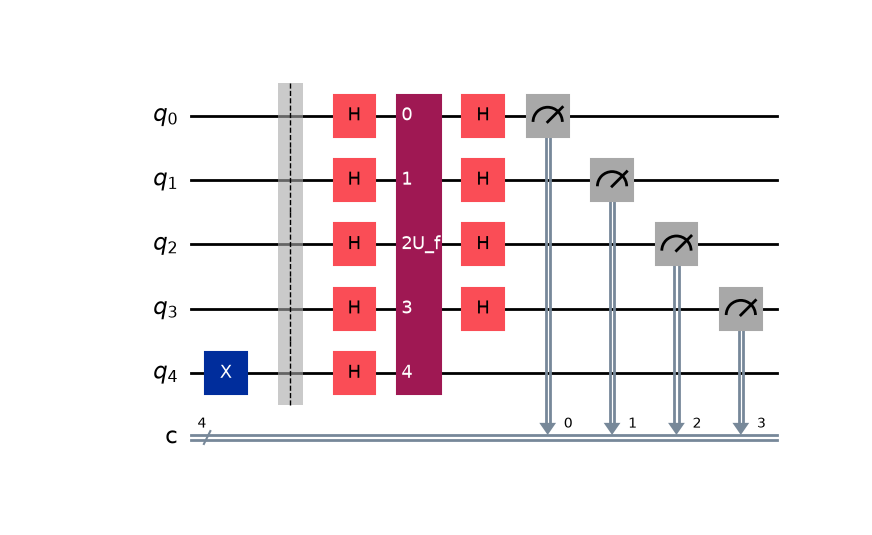

In [ ]:
!pip install qiskit qiskit[visualization]
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import BitFlipOracleGate
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


## Schritt 1: Grundeinstellungen

Wir legen fest:

- `N` – die Anzahl der Eingabe-Qubits (bei uns 4)
- `F_CONSTANT` – ein Schalter, mit dem du später zwischen konstantem und balanciertem Orakel umschalten kannst
- `expression` – ein boolescher Ausdruck als Python-String, der unsere **balancierte** Testfunktion beschreibt

Eine mögliche balancierte Funktion, die wir verwenden könnten, lautet:

$$f(x_1,x_2,x_3,x_4) = \overline{(x_1 \lor x_2 \lor x_3 \lor x_4)} \;\lor\; (x_1 \land x_3) \;\lor\; (x_2 \land x_4)$$

Du kannst dir aber auch einen eigenen Ausdruck auf den Bits überlegen.

Aus der Dokumentation von Qiskit:
>A logical expression is composed of logical operators & (logical AND), | (logical OR), ~ (logical NOT), and ^ (logical XOR). as well as symbols for literals (variables). For example, ‘a & b’, and (v0 | ~v1) & (~v2 & v3) are both valid string representation of boolean logical expressions.

In [ ]:
N = 4

F_CONSTANT = False

expression = ... # logical expression string for a balanced function here


## Schritt 2: Das balancierte Orakel bauen

Jetzt wird es interessant: Wir wollen aus dem `expression`-String automatisch ein Quantengatter machen, das den Zustand des Hilfs-Qubits umkippt (*bit-flip*), wenn $f(x)=1$ ist – genau das, was wir für den Algorithmus brauchen.

Qiskit bringt dafür ein fertiges Gatter mit: **`BitFlipOracleGate`**. Es erstellt ein Query Gate für eine Funktion, die man durch einen booleschen Ausdruck als `string` beschreibt.

> 💡 **Tipp:** Schau dir die Qiskit-Dokumentation zu [`BitFlipOracleGate`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.BitFlipOracleGate) an. Du wirst dort sehen, dass der Konstruktor u. a. folgende Parameter erwartet:
>
> - den booleschen Ausdruck als String
> - `var_order`: eine Liste, die festlegt, in welcher Reihenfolge die Variablen ($x_1$ bis $x_4$) auf die Qubits gemappt werden
> - optional ein `label` für die Darstellung im Circuit-Diagramm (z. B. `"U_f"`)

**Deine Aufgabe:** Erzeuge das Gatter `balanced_query_gate` mithilfe von `BitFlipOracleGate`. Achte darauf, dass `var_order` die Variablen `x1` bis `x4` in der richtigen Reihenfolge enthält (Tipp: Das lässt sich mit einer List Comprehension über `range(N)` sehr kompakt schreiben, z. B. `f"x{{n+1}}"`).

In [ ]:
# TODO: Erzeuge balanced_query_gate mit BitFlipOracleGate
# balanced_query_gate = BitFlipOracleGate(
#     ...,
#     var_order=...,
#     label="U_f"
# )


## Schritt 3: Das konstante Orakel bauen

Zum Vergleich (und damit du später `F_CONSTANT` umschalten und beide Fälle testen kannst) brauchen wir auch ein Orakel für eine **konstante** Funktion, z. B. $f(x) = 0$ für alle $x$.

Ein Orakel, das $f(x)=0$ realisiert, tut schlicht **gar nichts** mit dem Hilfs-Qubit – es ist einfach die Identität.

> 💡 **Tipp:** Ein "leerer" `QuantumCircuit` (ohne jegliche Gatter) *ist* bereits die Identitätsoperation. Mit der Methode [`.to_gate()`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#to_gate) lässt sich ein `QuantumCircuit`-Objekt in ein einzelnes Gatter umwandeln, das du danach wie jedes andere Gatter in einen größeren Circuit einfügen kannst. Denke daran, dass dieser Teil-Circuit genauso viele Qubits braucht wie unser Gesamtcircuit Eingabe- plus Hilfs-Qubits hat (also `N+1`).

**Deine Aufgabe:** Erzeuge `constant_query_gate` als leeren `QuantumCircuit` mit `N+1` Qubits, den du direkt in ein Gatter umwandelst. Gib ihm zur Übersicht einen sprechenden `name`, z. B. `"f(x) = 0"`.

In [ ]:
# TODO: Erzeuge constant_query_gate als "leeres" Gatter (Identität) über N+1 Qubits
# constant_query_gate = QuantumCircuit(..., name=...).to_gate()


## Schritt 4: Den Deutsch-Jozsa-Circuit zusammensetzen

Baue nun den vollständigen Circuit selbstständig auf. Er benötigt `N + 1` Qubits und `N` klassische Bits.

Bereite zuerst das Hilfs-Qubit am Index `N` im Zustand $|1\rangle$ vor. Wende anschließend Hadamard-Gatter auf alle Qubits an. Danach fügst du das bereits definierte Orakel als zusammengesetztes Gatter in den Circuit ein: Mit der `append`-Methode kann ein vorgefertigtes Gate an einen Circuit angehängt werden. Dabei gibst du zuerst das Gate und anschließend die Qubits an, auf denen es wirken soll. Das Orakel verwendet alle `N + 1` Qubits; wähle abhängig von `F_CONSTANT` entweder das konstante oder das balancierte Gate.

Nach dem Orakel folgt eine zweite Hadamard-Runde, diesmal nur auf den `N` Eingabe-Qubits. Miss zum Schluss diese Eingabe-Qubits in die `N` klassischen Bits. Eine Barriere nach der Vorbereitung des Hilfs-Qubits ist optional und dient nur der besseren Darstellung.

In [ ]:
# Your code here
qc = QuantumCircuit(N+1, N) # N+1 qubits, N classical bits for measuring
# ...

## Schritt 5: Circuit anschauen

Zeichnen wir den fertigen Circuit einmal auf – vergleiche das Ergebnis mit der Illustration ganz oben im Notebook!

In [ ]:
qc.draw("mpl", idle_wires=False)


## Schritt 6: Simulation und Auswertung

Jetzt lassen wir den Circuit auf einem Simulator laufen und schauen uns die Messergebnisse an. Dafür verwenden wir den `StatevectorSampler` und lassen den Circuit `2**16` mal ("Shots") ausführen.

Diese Zelle ist vollständig vorgegeben – führe sie aus, nachdem du alle TODOs oben ausgefüllt hast.

In [ ]:
sampler = StatevectorSampler()
result = sampler.run([qc], shots=2**16).result()
counts = result[0].data.c.get_counts()

plot_histogram(counts)
plt.show()


## Ergebnis interpretieren

Schau dir das Histogramm an:

- Siehst du **nur** den Balken `0000`? Dann hat der Algorithmus korrekt erkannt, dass die Funktion **konstant** ist.
- Siehst du irgendeinen **anderen** Bitstring (oder eine Mischung, aber **nie** `0000`)? Dann war die Funktion **balanciert**.

**Zum Ausprobieren:**

1. Setze oben in Schritt 1 `F_CONSTANT = True` und führe das Notebook erneut aus. Was passiert mit dem Histogramm?
2. Verändere den `expression`-String zu einer eigenen booleschen Funktion. Ist sie konstant oder balanciert? Überprüfe deine Vermutung mit dem Circuit!
3. Was würde passieren, wenn du Schritt 8 (die zweite Hadamard-Runde) weglässt? Probiere es aus und überlege dir, warum das Ergebnis dann nicht mehr aussagekräftig ist.